# CNN_Crack_3_Conv_Layer_ReLU_Dropout

### 표면의 Crack 여부를 파악하는 시스템을 3 Conv Layer + ReLU + Dropout을 이용한 CNN으로 구현하라
### (Colab을 사용하는 경우 "files/crack.zip"을 "내 드라이브/files/"에 복사)

>### Load modules

In [1]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import glob
import cv2
from sklearn.model_selection import train_test_split

print("NumPy Version :{}".format(np.__version__))
print("TensorFlow Version :{}".format(tf.__version__))
print("Matplotlib Version :{}".format(plt.matplotlib.__version__))

NumPy Version :1.26.4
TensorFlow Version :2.18.0
Matplotlib Version :3.10.0


> ### Load Data

In [2]:
colab=True
try:
  from google.colab import drive
except:
  colab =False
if colab :
    drive.mount('/content/drive')
    print('g-drive mounted.')
else : print('local drive.')

Mounted at /content/drive
g-drive mounted.


In [3]:
# file path: 다른 경로에 실습파일을 복사했다면, 아래 경로를 수정하세요

if colab :
  !unzip -q -o /content/drive/MyDrive/[SOL]LAB_09_CNN_Crack_3_Conv_Layer_ReLU_Dropout/files/crack.zip
  files_path = '/content/crack'
else :
  files_path = '../files/crack/crack'

In [ ]:
# 1. 데이터 읽기

In [4]:
%%time


/content/crack/0/*.*
/content/crack/1/*.*
CPU times: user 1.39 s, sys: 166 ms, total: 1.55 s
Wall time: 3.13 s


In [5]:
# 2. 전처리: 0 ~ 1로 변환


(3200, 64, 64, 3)
(3200,)
(800, 64, 64, 3)
(800,)


In [7]:
# 3. Keras Model 정의, Model summary


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)                    │ (None, 64, 64, 64)          │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 64, 64, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 32, 32, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 32, 32, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 32, 32, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 16, 16, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 16, 16, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 16, 16, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 8, 8, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 4096)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 2)                   │           8,194 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 83,842 (327.51 KB)

 Trainable params: 83,842 (327.51 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
# 4. Model compile


In [9]:
# 5. Make_Result_Plot() 함수 정의 -> 출력 정보에 정답 여부 출력 (정답은 O, 오답은 X)


25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step


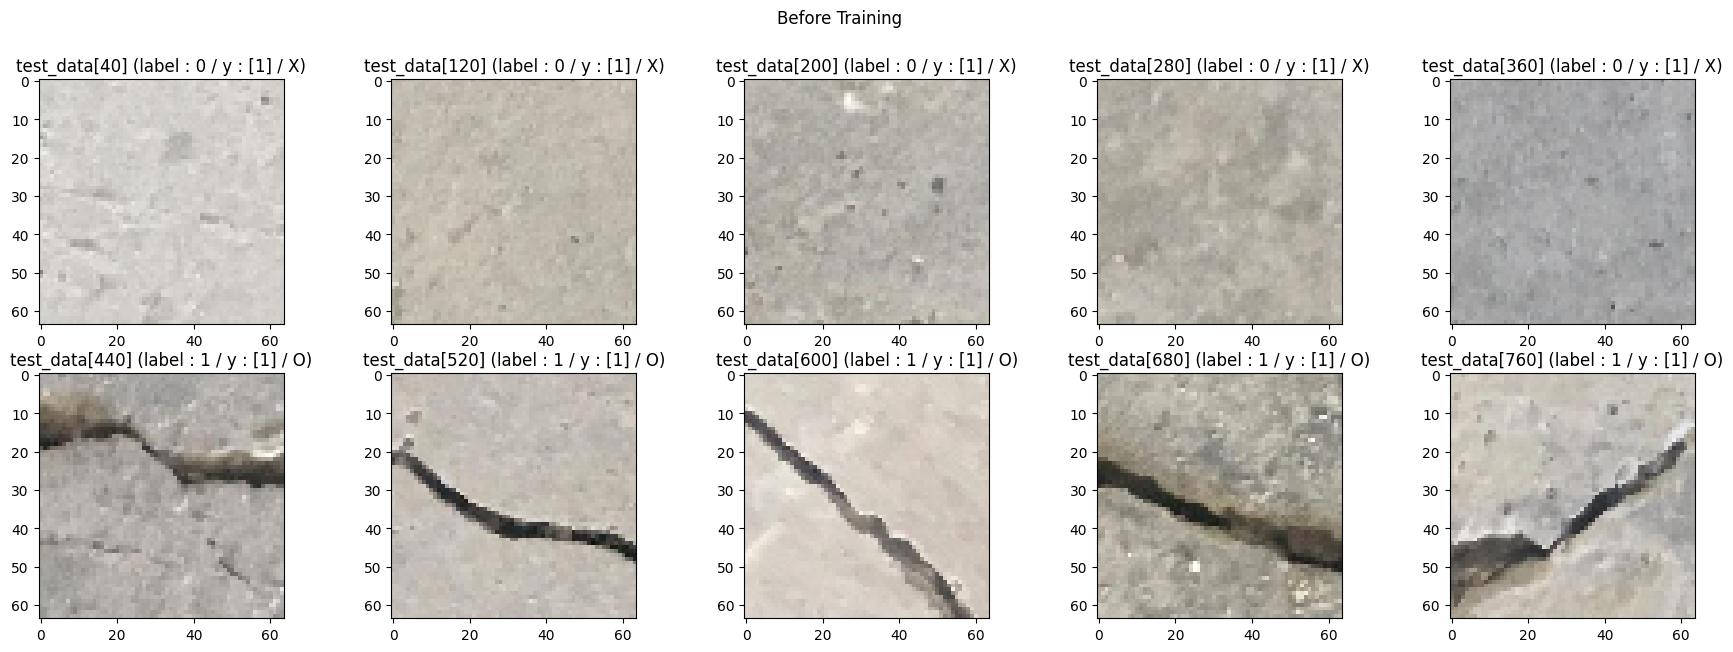

In [10]:
# 6. 학습 전 상황 그리기


In [ ]:
# 7. Model fit

In [11]:
%%time


Epoch 1/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.6000 - loss: 0.6423 - val_accuracy: 0.9750 - val_loss: 0.2035
Epoch 2/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9668 - loss: 0.1028 - val_accuracy: 0.9912 - val_loss: 0.1511
Epoch 3/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9882 - loss: 0.0450 - val_accuracy: 0.9912 - val_loss: 0.0954
Epoch 4/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9887 - loss: 0.0307 - val_accuracy: 0.9900 - val_loss: 0.1104
Epoch 5/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9807 - loss: 0.0548 - val_accuracy: 0.9912 - val_loss: 0.0993
Epoch 6/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9778 - loss: 0.0650 - val_accuracy: 0.9625 - val_loss: 0.2927
Epoch 7/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9583 - loss: 0.1020 - val_accuracy: 0.9887 - val_loss: 0.1060
Epoch 8/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9885 - loss: 0.0356 - val_accuracy

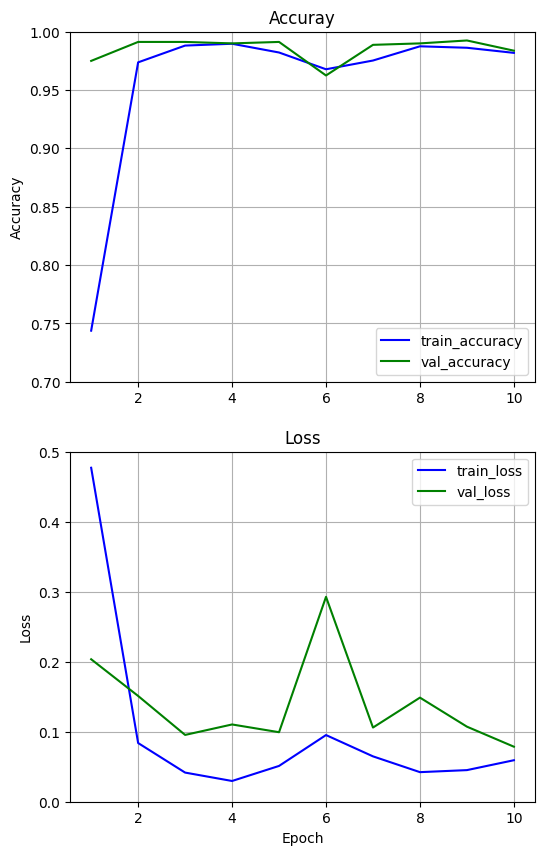

In [12]:
# 8. accuray, loss 그래프 출력


> ### Training 이후

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


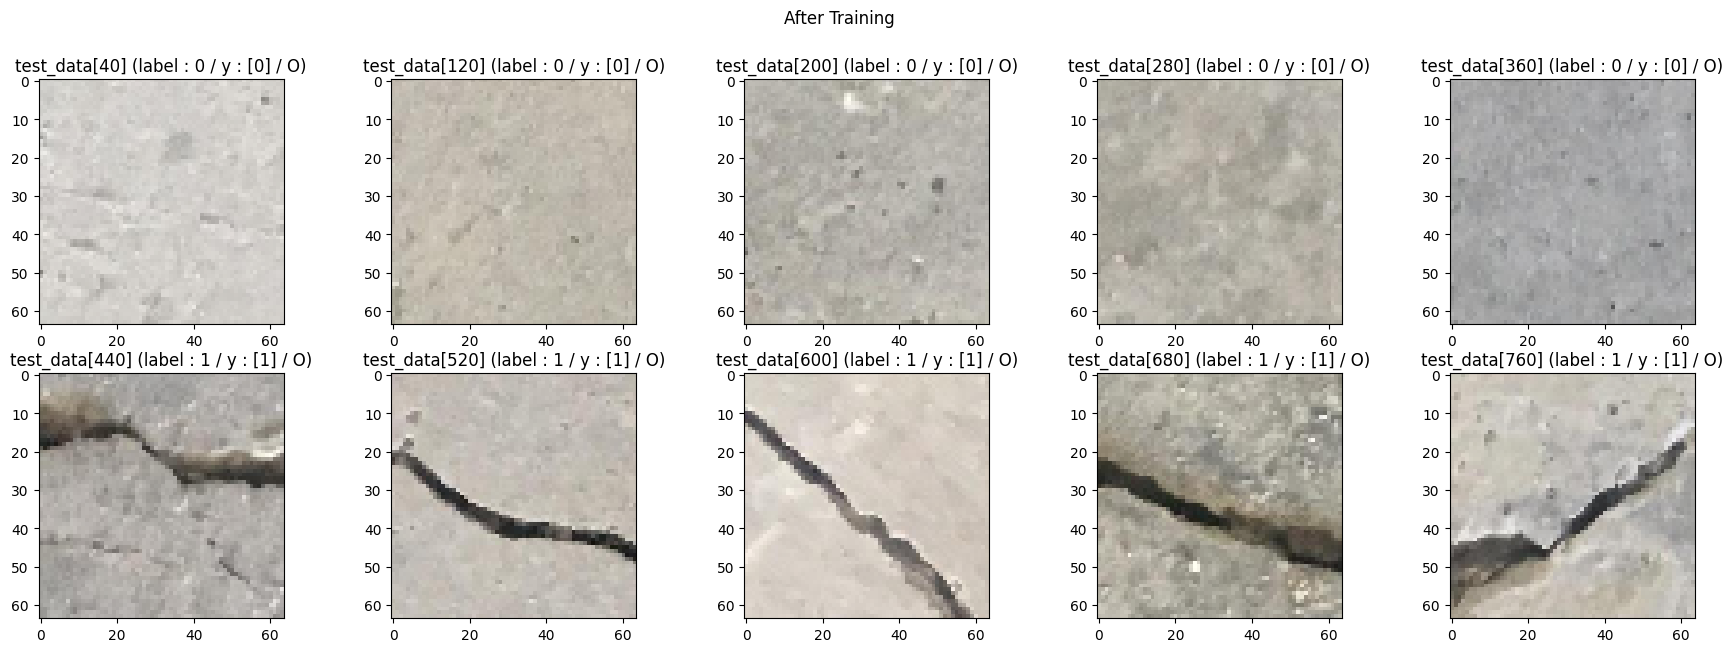

In [13]:
# 9. 학습 후 상황 그리기
